In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from edge_detection import *
from line_detection import *
from nfa import validate_lines

path = "../images/test.png"


In [2]:
img = cv2.imread("../images/test.png",0)

(np.float64(-0.5), np.float64(389.5), np.float64(469.5), np.float64(-0.5))

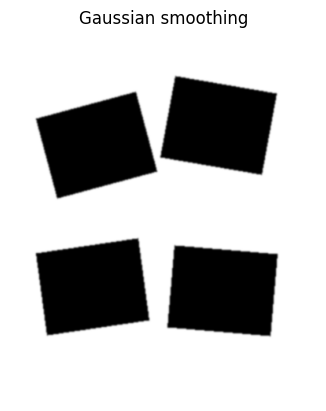

In [3]:
smooth = gaussian_smoothing(img)

plt.imshow(smooth, cmap="gray")
plt.title("Gaussian smoothing")
plt.axis("off")

(np.float64(-0.5), np.float64(389.5), np.float64(469.5), np.float64(-0.5))

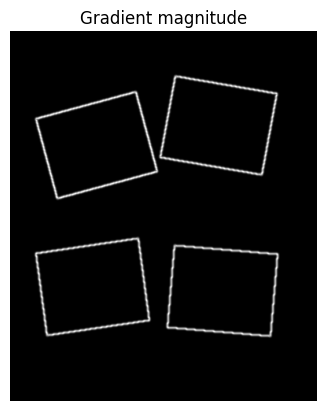

In [4]:
smooth = gaussian_smoothing(img)

G, D = compute_gradient(smooth)

plt.imshow(G, cmap="gray")
plt.title("Gradient magnitude")
plt.axis("off")

(np.float64(-0.5), np.float64(389.5), np.float64(469.5), np.float64(-0.5))

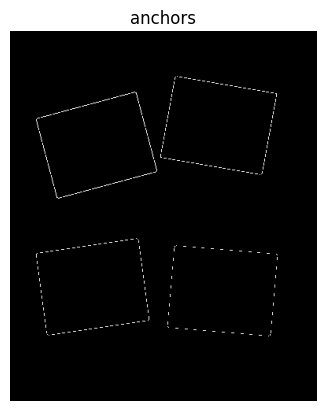

In [5]:
anchors = compute_anchors(G, D)
anchors_img = np.zeros_like(img)

for y, x in anchors:
    anchors_img[y, x] = 255

plt.imshow(anchors_img, cmap="gray")
plt.title("anchors")
plt.axis("off")

In [6]:
edges = edge_drawing(G, D, anchors)
edge_img = np.zeros_like(img)

for edge in edges:
    for y,x in edge:
        edge_img[y,x] = 255

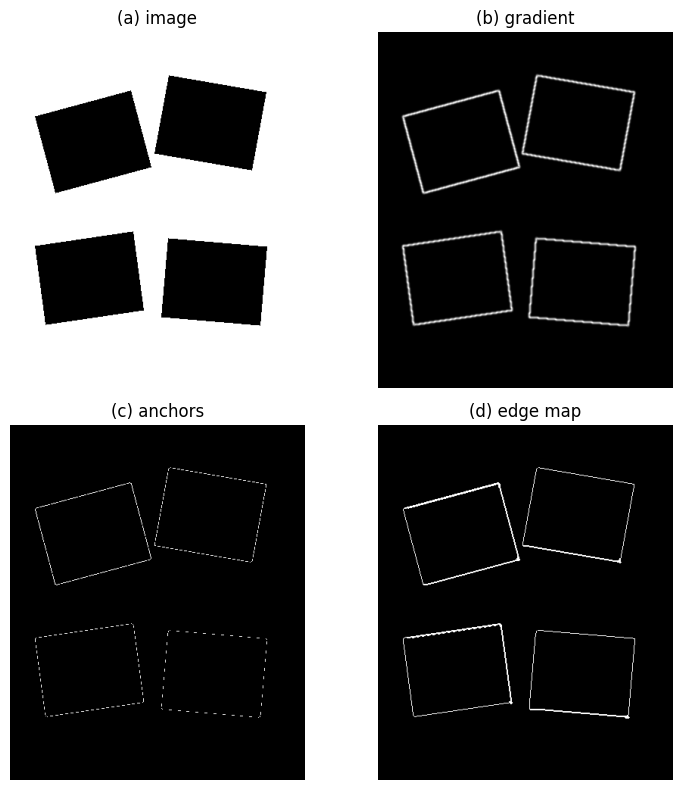

In [7]:
fig, ax = plt.subplots(2,2, figsize=(8,8))

ax[0,0].imshow(img, cmap="gray")
ax[0,0].set_title("(a) image")

ax[0,1].imshow(G, cmap="gray")
ax[0,1].set_title("(b) gradient")

ax[1,0].imshow(anchors_img, cmap="gray")
ax[1,0].set_title("(c) anchors")

ax[1,1].imshow(edge_img, cmap="gray")
ax[1,1].set_title("(d) edge map")

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()

In [8]:
lines = detect_lines(edges)

In [9]:
angles = [compute_line_angle(line) for line in lines]

(np.float64(-0.5), np.float64(389.5), np.float64(469.5), np.float64(-0.5))

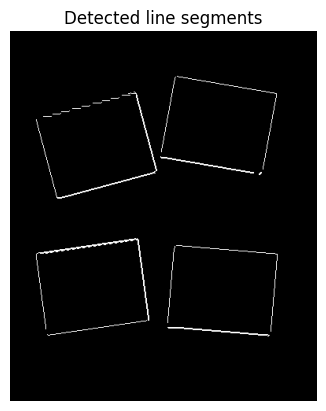

In [10]:
line_img = np.zeros_like(img)

for line in lines:
    for y, x in line:
        line_img[y, x] = 255

plt.imshow(line_img, cmap="gray")
plt.title("Detected line segments")
plt.axis("off")

In [11]:
gx_map = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=1)
gy_map = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=1)

valid_lines = validate_lines(lines, gx_map, gy_map, img.shape, eps=10.0)
print(f"Lignes brutes   : {len(lines)}")
print(f"Lignes valides  : {len(valid_lines)}")

Lignes brutes   : 125
Lignes valides  : 23


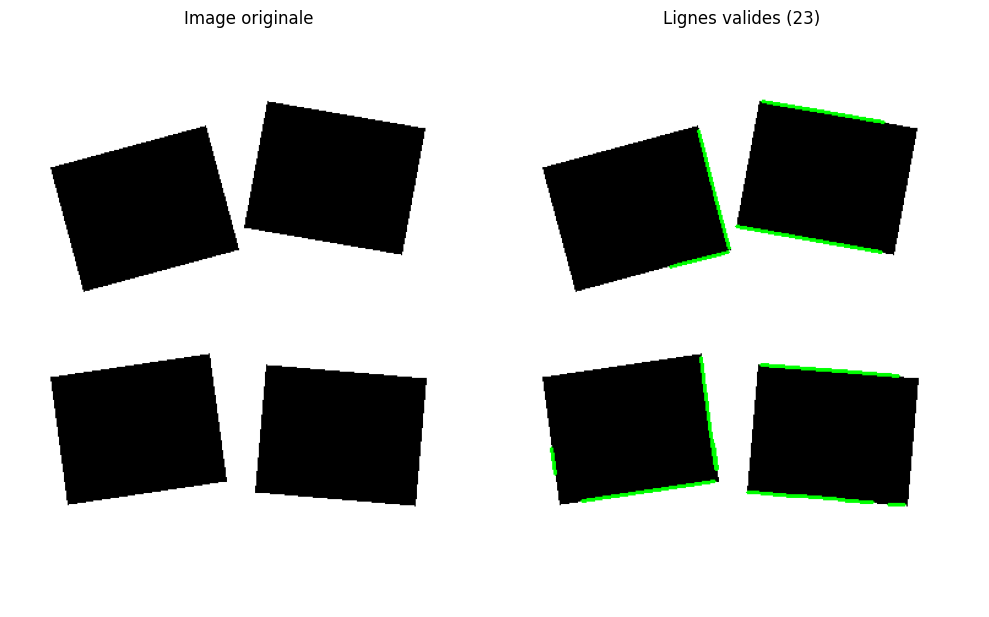

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def visualize_lines(img, valid_lines, line_color=(0, 255, 0), thickness=2):
    """Dessine les lignes valides sur l'image."""
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    
    for seg in valid_lines:
        y0, x0 = seg[0]
        y1, x1 = seg[-1]
        cv2.line(vis, (x0, y0), (x1, y1), line_color, thickness)
    
    return vis

vis = visualize_lines(img, valid_lines)

plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title(f"Image originale")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"Lignes valides ({len(valid_lines)})")
plt.axis('off')

plt.tight_layout()
plt.show()

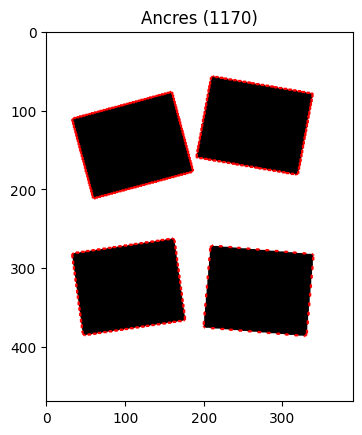

In [13]:
anchor_img = cv2.cvtColor(img.copy(), cv2.COLOR_GRAY2BGR)
for y, x in anchors:
    cv2.circle(anchor_img, (x, y), 1, (0, 0, 255), -1)

plt.imshow(cv2.cvtColor(anchor_img, cv2.COLOR_BGR2RGB))
plt.title(f"Ancres ({len(anchors)})")
plt.show()

Edges     : 5
Lignes brutes  : 0
Lignes valides : 0


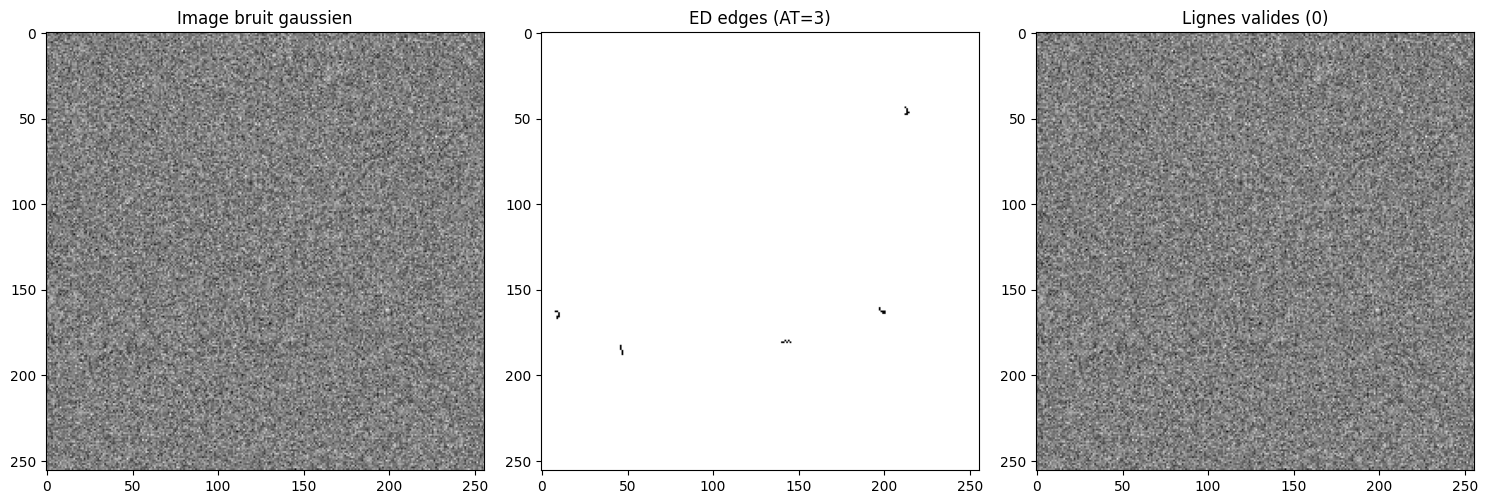

In [16]:
import numpy as np

# Générer une image de bruit gaussien pur (comme dans le papier)
np.random.seed(42)
noise_img = np.random.normal(128, 30, (256, 256)).clip(0, 255).astype(np.uint8)

# Faire tourner le pipeline complet
gx_map = cv2.Sobel(noise_img, cv2.CV_64F, 1, 0, ksize=1)
gy_map = cv2.Sobel(noise_img, cv2.CV_64F, 0, 1, ksize=1)

smooth  = gaussian_smoothing(noise_img)
G, D    = compute_gradient(smooth)
anchors = compute_anchors(G, D, anchor_threshold=3)  # AT=1 puis AT=3
edges   = edge_drawing(G, D, anchors)
lines   = detect_lines(edges)
valid_lines = validate_lines(lines, gx_map, gy_map, noise_img.shape, eps=1.0)

print(f"Edges     : {len(edges)}")
print(f"Lignes brutes  : {len(lines)}")
print(f"Lignes valides : {len(valid_lines)}")  # doit être 0

# Visualiser
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(noise_img, cmap='gray')
axes[0].set_title("Image bruit gaussien")

edge_img = np.ones_like(noise_img) * 255
for edge in edges:
    for y, x in edge:
        edge_img[y, x] = 0
axes[1].imshow(edge_img, cmap='gray')
axes[1].set_title(f"ED edges (AT=3)")

vis = visualize_lines(noise_img, valid_lines)
axes[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Lignes valides ({len(valid_lines)})")

plt.tight_layout()
plt.show()

Edges     : 268
Lignes brutes  : 195
Lignes valides : 58


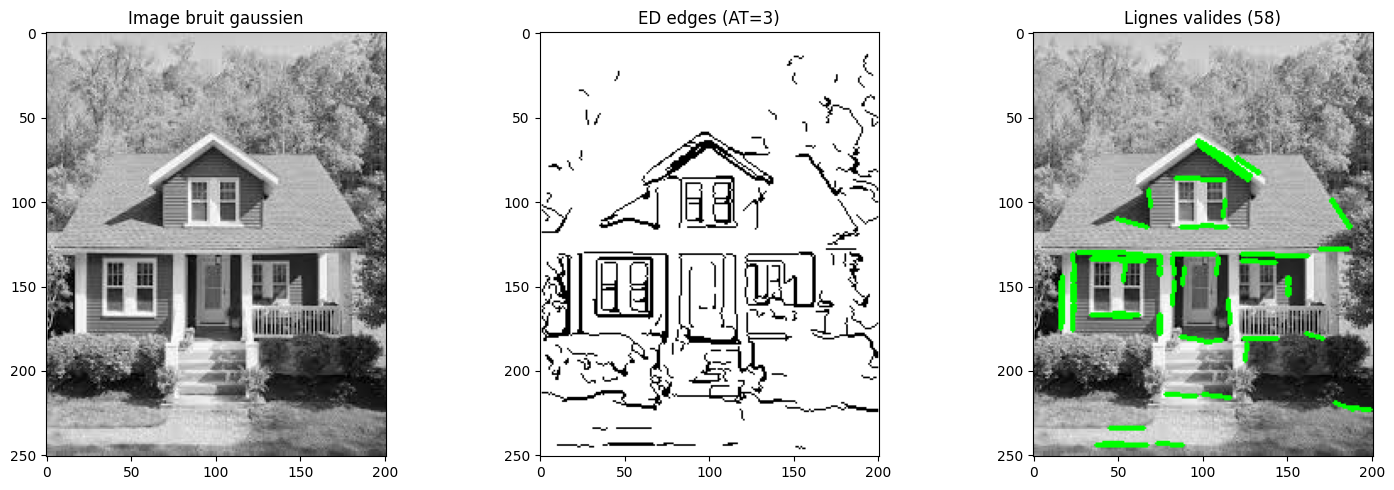

In [18]:
import numpy as np

# Générer une image de bruit gaussien pur (comme dans le papier)
np.random.seed(42)
noise_img = cv2.imread("../images/house.jpeg",0)

# Faire tourner le pipeline complet
gx_map = cv2.Sobel(noise_img, cv2.CV_64F, 1, 0, ksize=1)
gy_map = cv2.Sobel(noise_img, cv2.CV_64F, 0, 1, ksize=1)

smooth  = gaussian_smoothing(noise_img)
G, D    = compute_gradient(smooth)
anchors = compute_anchors(G, D, anchor_threshold=3)  # AT=1 puis AT=3
edges   = edge_drawing(G, D, anchors)
lines   = detect_lines(edges)
valid_lines = validate_lines(lines, gx_map, gy_map, noise_img.shape, eps=1.0)

print(f"Edges     : {len(edges)}")
print(f"Lignes brutes  : {len(lines)}")
print(f"Lignes valides : {len(valid_lines)}")  # doit être 0

# Visualiser
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(noise_img, cmap='gray')
axes[0].set_title("Image bruit gaussien")

edge_img = np.ones_like(noise_img) * 255
for edge in edges:
    for y, x in edge:
        edge_img[y, x] = 0
axes[1].imshow(edge_img, cmap='gray')
axes[1].set_title(f"ED edges (AT=3)")

vis = visualize_lines(noise_img, valid_lines)
axes[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Lignes valides ({len(valid_lines)})")

plt.tight_layout()
plt.show()